# 10 — Test: NDVI filtrado a soja vs original en predicción

Compara las predicciones del modelo existente (entrenado con NDVI sin filtrar)
cuando se le da como input features construidas con NDVI filtrado a soja.

Solo cubre 5 campañas (2019/20 a 2023/24) donde hay MNC disponible.

In [1]:
import os
os.chdir(r'C:\Users\agust\Documents\rinde-soja')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

## 1. Cargar datos

In [2]:
# NDVI filtrado a soja (del notebook 09)
df_soja = pd.read_csv('data/raw/ndvi/ndvi_modis_soja_filtrado_zona_coop.csv')
df_soja['fecha'] = pd.to_datetime(df_soja['fecha'])

# NDVI original sin filtrar
df_orig = pd.read_csv('data/raw/ndvi/ndvi_modis_zona_coop_2000_2025.csv')
df_orig['fecha'] = pd.to_datetime(df_orig['fecha'])
df_orig['partido'] = df_orig['partido'].str.replace('Junín', 'Junin')

# Dataset de modelado existente (features + target, 125 filas)
df_modelo = pd.read_csv('data/processed/dataset_modelado_soja.csv')

print(f'NDVI filtrado: {len(df_soja)} filas')
print(f'Dataset modelado: {df_modelo.shape}')

NDVI filtrado: 275 filas
Dataset modelado: (125, 70)


## 2. Feature engineering con NDVI filtrado

Replicamos las mismas features NDVI que el notebook 03
pero usando el NDVI filtrado a soja.

In [3]:
# Ver features NDVI del dataset de modelado
ndvi_cols = [c for c in df_modelo.columns if 'ndvi' in c.lower()]
print('Features NDVI en el modelo:')
for c in sorted(ndvi_cols):
    print(f'  {c}')

Features NDVI en el modelo:
  ndvi_max_oct_dic
  ndvi_max_oct_ene
  ndvi_max_oct_feb
  ndvi_max_oct_mar
  ndvi_max_oct_nov
  ndvi_mean_oct_dic
  ndvi_mean_oct_ene
  ndvi_mean_oct_feb
  ndvi_mean_oct_mar
  ndvi_mean_oct_nov
  ndvi_min_oct_dic
  ndvi_min_oct_ene
  ndvi_min_oct_feb
  ndvi_min_oct_mar
  ndvi_min_oct_nov
  ndvi_slope_oct_dic
  ndvi_slope_oct_ene
  ndvi_slope_oct_feb
  ndvi_slope_oct_mar
  ndvi_slope_oct_nov
  ndvi_std_oct_dic
  ndvi_std_oct_ene
  ndvi_std_oct_feb
  ndvi_std_oct_mar
  ndvi_std_oct_nov


## 3. Construir features NDVI filtrado por ventana

In [9]:
VENTANAS = {
    'oct_nov': (10, 11),
    'oct_dic': (10, 12),
    'oct_ene': (10, 1),
    'oct_feb': (10, 2),
    'oct_mar': (10, 3),
}

CAMPANAS_MNC = {
    '2019/20': 2020,
    '2020/21': 2021,
    '2021/22': 2022,
    '2022/23': 2023,
    '2023/24': 2024,
}

PARTIDOS = ['General Arenales', 'General Pinto', 'Junin', 'Leandro N. Alem', 'Lincoln']

def mes_en_ventana(mes, mes_inicio, mes_fin):
    if mes_inicio <= mes_fin:
        return mes_inicio <= mes <= mes_fin
    else:
        return mes >= mes_inicio or mes <= mes_fin

def calcular_features_ndvi(df_ndvi, campana_str, campana):
    sub = df_ndvi[df_ndvi['campana'] == campana_str].copy()
    sub['mes'] = sub['fecha'].dt.month
    col_ndvi = 'ndvi_soja_mean' if 'ndvi_soja_mean' in sub.columns else 'ndvi'
    
    filas = []
    for partido in PARTIDOS:
        sp = sub[sub['partido'] == partido].copy().sort_values('fecha')
        if len(sp) == 0:
            continue
        
        fila = {'partido': partido, 'campana': campana}
        
        for ventana_nombre, (mes_ini, mes_fin) in VENTANAS.items():
            mask = sp['mes'].apply(lambda m: mes_en_ventana(m, mes_ini, mes_fin))
            sw = sp[mask]
            
            if len(sw) > 0:
                vals = sw[col_ndvi].dropna()
                if len(vals) > 0:
                    fila[f'ndvi_mean_{ventana_nombre}'] = vals.mean()
                    fila[f'ndvi_max_{ventana_nombre}'] = vals.max()
                    fila[f'ndvi_min_{ventana_nombre}'] = vals.min()
                    fila[f'ndvi_std_{ventana_nombre}'] = vals.std() if len(vals) > 1 else 0
                    # Slope: pendiente lineal del NDVI en la ventana
                    if len(vals) > 1:
                        x = np.arange(len(vals))
                        fila[f'ndvi_slope_{ventana_nombre}'] = np.polyfit(x, vals.values, 1)[0]
                    else:
                        fila[f'ndvi_slope_{ventana_nombre}'] = 0
        
        filas.append(fila)
    
    return filas

filas_filtrado = []
for campana_str, campana in CAMPANAS_MNC.items():
    filas_filtrado.extend(calcular_features_ndvi(df_soja, campana_str, campana))

df_feat_filtrado = pd.DataFrame(filas_filtrado)
print(f'Features NDVI filtrado: {df_feat_filtrado.shape}')
print(f'Campanas: {sorted(df_feat_filtrado["campana"].unique())}')
df_feat_filtrado.head()      

Features NDVI filtrado: (25, 27)
Campanas: [2020, 2021, 2022, 2023, 2024]


,partido,campana,ndvi_mean_oct_nov,ndvi_max_oct_nov,ndvi_min_oct_nov,ndvi_std_oct_nov,ndvi_slope_oct_nov,ndvi_mean_oct_dic,ndvi_max_oct_dic,ndvi_min_oct_dic,...,ndvi_mean_oct_feb,ndvi_max_oct_feb,ndvi_min_oct_feb,ndvi_std_oct_feb,ndvi_slope_oct_feb,ndvi_mean_oct_mar,ndvi_max_oct_mar,ndvi_min_oct_mar,ndvi_std_oct_mar,ndvi_slope_oct_mar
0,General Arenales,2020,0.497820,0.528504,0.458182,0.036006,-0.035161,0.524863,0.664748,0.458182,...,0.659578,0.880217,0.458182,0.175319,0.058050,0.670246,0.880217,0.458182,0.163282,0.035675
1,General Pinto,2020,0.542476,0.584130,0.480014,0.055088,-0.052058,0.543490,0.620057,0.469966,...,0.665163,0.872704,0.469966,0.155800,0.048572,0.677036,0.872704,0.469966,0.144446,0.031281
2,Junin,2020,0.503566,0.530634,0.461084,0.037250,-0.034775,0.520776,0.635529,0.457651,...,0.648033,0.872967,0.457651,0.167792,0.055360,0.664571,0.872967,0.457651,0.157770,0.036991
3,Leandro N. Alem,2020,0.494284,0.526198,0.448820,0.040429,-0.038689,0.518970,0.650495,0.448820,...,0.655570,0.870456,0.448820,0.174003,0.057132,0.665394,0.870456,0.448820,0.161554,0.034823
4,Lincoln,2020,0.507010,0.527783,0.470627,0.031614,-0.028578,0.520873,0.630876,0.452456,...,0.655753,0.866361,0.452456,0.169727,0.055420,0.665294,0.866361,0.452456,0.156186,0.033913


## 4. Verificar que los nombres de features coincidan

In [10]:
ndvi_feat_filtrado = [c for c in df_feat_filtrado.columns if 'ndvi' in c]
ndvi_feat_modelo = [c for c in df_modelo.columns if 'ndvi' in c]

comunes = sorted(set(ndvi_feat_modelo) & set(ndvi_feat_filtrado))
solo_modelo = sorted(set(ndvi_feat_modelo) - set(ndvi_feat_filtrado))
solo_filtrado = sorted(set(ndvi_feat_filtrado) - set(ndvi_feat_modelo))

print(f'Comunes: {len(comunes)}')
print(f'Solo en modelo: {len(solo_modelo)} → {solo_modelo[:5]}')
print(f'Solo en filtrado: {len(solo_filtrado)} → {solo_filtrado[:5]}')

if len(comunes) == 0:
    print('')
    print('⚠ Los nombres no coinciden. Revisar feature engineering del notebook 03.')
    print('Modelo:', ndvi_feat_modelo[:5])
    print('Filtrado:', ndvi_feat_filtrado[:5])

Comunes: 25
Solo en modelo: 0 → []
Solo en filtrado: 0 → []


## 5. Walk-forward: predecir con features originales vs filtradas

Para cada campaña MNC:
1. Entrenar RF con todas las campañas anteriores (features originales)
2. Predecir la campaña test con features originales → error original
3. Predecir la campaña test reemplazando features NDVI por las filtradas → error filtrado

In [11]:
campanas_test = sorted(CAMPANAS_MNC.values())

feature_cols = [c for c in df_modelo.columns 
                if c not in ['partido', 'campana', 'rinde_qq_ha', 
                             'superficie_sembrada_ha', 'superficie_cosechada_ha']]

resultados = []

for campana_test in campanas_test:
    df_train = df_modelo[df_modelo['campana'] < campana_test].copy()
    
    if len(df_train) < 10:
        print(f'Campana {campana_test}: muy pocos datos ({len(df_train)}), skip')
        continue
    
    use_features = [c for c in feature_cols if c in df_train.columns]
    
    X_train = df_train[use_features].fillna(0)
    y_train = df_train['rinde_qq_ha']
    
    rf = RandomForestRegressor(n_estimators=200, random_state=42, max_features=0.33)
    rf.fit(X_train, y_train)
    
    # Prediccion con features ORIGINALES
    df_test_orig = df_modelo[df_modelo['campana'] == campana_test].copy()
    X_test_orig = df_test_orig[use_features].fillna(0)
    y_test = df_test_orig['rinde_qq_ha']
    pred_orig = rf.predict(X_test_orig)
    
    # Prediccion con features FILTRADAS (reemplazar solo NDVI)
    df_test_filt = df_test_orig.copy()
    filt_campana = df_feat_filtrado[df_feat_filtrado['campana'] == campana_test]
    
    for partido in PARTIDOS:
        mask_test = df_test_filt['partido'] == partido
        mask_filt = filt_campana['partido'] == partido
        
        if mask_filt.sum() == 0:
            continue
        
        filt_row = filt_campana[mask_filt].iloc[0]
        
        for col in comunes:
            if col in df_test_filt.columns:
                df_test_filt.loc[mask_test, col] = filt_row[col]
    
    X_test_filt = df_test_filt[use_features].fillna(0)
    pred_filt = rf.predict(X_test_filt)
    
    for i, partido in enumerate(df_test_orig['partido'].values):
        resultados.append({
            'campana': campana_test,
            'partido': partido,
            'rinde_real': y_test.values[i],
            'pred_original': pred_orig[i],
            'pred_filtrado': pred_filt[i],
            'error_original': abs(pred_orig[i] - y_test.values[i]),
            'error_filtrado': abs(pred_filt[i] - y_test.values[i]),
        })
    
    mae_o = mean_absolute_error(y_test, pred_orig)
    mae_f = mean_absolute_error(y_test, pred_filt)
    print(f'Campana {campana_test}: MAE original={mae_o:.2f}, MAE filtrado={mae_f:.2f}, diff={mae_f-mae_o:+.2f}')

df_res = pd.DataFrame(resultados)
print('')
print('=' * 60)
print(f'MAE global original:  {df_res["error_original"].mean():.2f} qq/ha')
print(f'MAE global filtrado:  {df_res["error_filtrado"].mean():.2f} qq/ha')
diff = df_res["error_filtrado"].mean() - df_res["error_original"].mean()
print(f'Diferencia:           {diff:+.2f} qq/ha')
print('=' * 60)

Campana 2020: MAE original=1.59, MAE filtrado=3.17, diff=+1.58
Campana 2021: MAE original=2.34, MAE filtrado=2.90, diff=+0.56
Campana 2022: MAE original=4.21, MAE filtrado=5.67, diff=+1.46
Campana 2023: MAE original=2.89, MAE filtrado=3.02, diff=+0.13
Campana 2024: MAE original=2.15, MAE filtrado=2.54, diff=+0.39

MAE global original:  2.64 qq/ha
MAE global filtrado:  3.46 qq/ha
Diferencia:           +0.82 qq/ha


## 6. Visualización

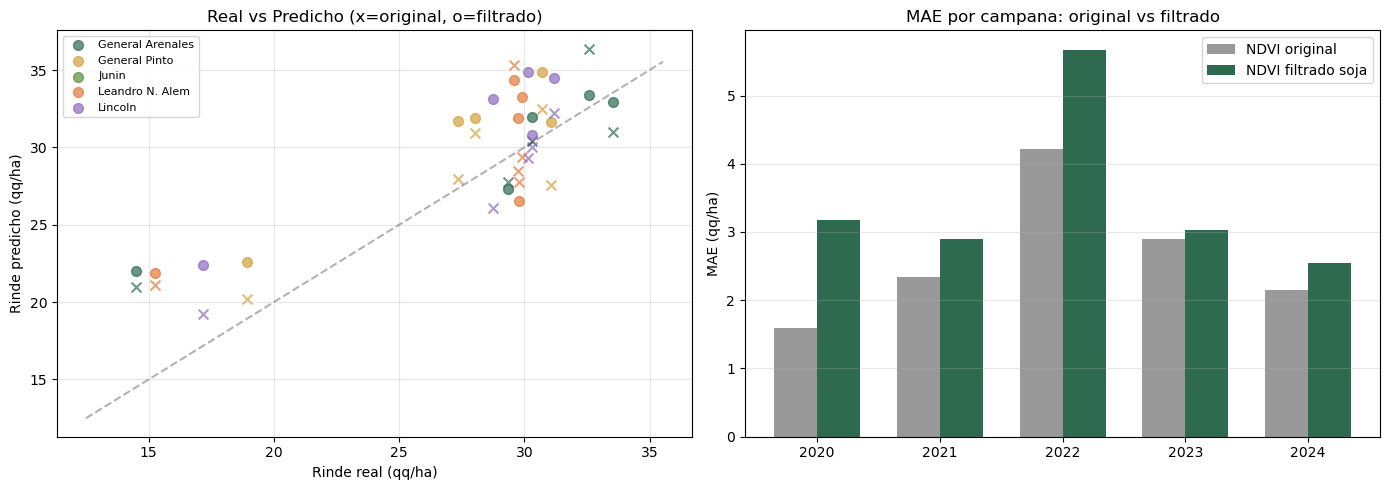

Figura guardada


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COLORES_PARTIDO = {
    'General Arenales': '#2D6A4F',
    'Leandro N. Alem': '#E07A3A',
    'Junin': '#5B8C3E',
    'Lincoln': '#8E6BBF',
    'General Pinto': '#D4A03C'
}

# Scatter: real vs predicho
for partido in PARTIDOS:
    sub = df_res[df_res['partido'] == partido]
    color = COLORES_PARTIDO[partido]
    axes[0].scatter(sub['rinde_real'], sub['pred_original'], 
                    color=color, marker='x', s=50, alpha=0.7)
    axes[0].scatter(sub['rinde_real'], sub['pred_filtrado'], 
                    color=color, marker='o', s=50, alpha=0.7, label=partido)

lims = [df_res['rinde_real'].min()-2, df_res['rinde_real'].max()+2]
axes[0].plot(lims, lims, 'k--', alpha=0.3)
axes[0].set_xlabel('Rinde real (qq/ha)')
axes[0].set_ylabel('Rinde predicho (qq/ha)')
axes[0].set_title('Real vs Predicho (x=original, o=filtrado)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bar: MAE por campana
campanas = sorted(df_res['campana'].unique())
mae_orig_camp = [df_res[df_res['campana']==c]['error_original'].mean() for c in campanas]
mae_filt_camp = [df_res[df_res['campana']==c]['error_filtrado'].mean() for c in campanas]

x = np.arange(len(campanas))
w = 0.35
axes[1].bar(x - w/2, mae_orig_camp, w, label='NDVI original', color='#999999')
axes[1].bar(x + w/2, mae_filt_camp, w, label='NDVI filtrado soja', color='#2D6A4F')
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(c) for c in campanas])
axes[1].set_ylabel('MAE (qq/ha)')
axes[1].set_title('MAE por campana: original vs filtrado')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/test_ndvi_filtrado_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada')

## Conclusión

El NDVI filtrado a píxeles de soja (MNC INTA) no mejoró las predicciones del modelo existente: el MAE global pasó de **2.64 a 3.46 qq/ha** (+0.82). El deterioro fue consistente en las 5 campañas testeadas.

Esto se explica por la **inconsistencia train/test**: el modelo fue entrenado con 20+ campañas de NDVI sin filtrar, donde la señal incluye vegetación no agrícola que actúa como "línea de base" aprendida. Al reemplazar las features por NDVI filtrado solo a soja — con valores más bajos en pre-emergencia y más altos en pico — el modelo interpreta esas diferencias como condiciones anómalas.

**Hallazgos:**
- La máscara de soja funciona correctamente: las curvas filtradas son más coherentes entre partidos y reflejan mejor la fenología del cultivo
- MODIS a 250m en una zona 45-55% sojera ya captura adecuadamente la señal del cultivo dominante sin necesidad de máscara
- Para aprovechar el filtrado sería necesario reentrenar el modelo completo con NDVI filtrado, lo cual requiere más de 5 campañas con MNC disponible

El análisis valida la robustez del enfoque original y documenta una vía de mejora futura cuando existan series MNC más largas.